# Example of the AiTLAS toolbox for generating feature embeddings using SatMAE++

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

## Define the FAIREOSchema for dataset import

In [2]:
from marshmallow import fields, validate
from aitlas.base.schemas import BaseDatasetSchema

class FAIREOObjectDetectionCocoSchema(BaseDatasetSchema):
    """
    Schema for configuring an object detection dataset given in COCO format.
    """
    data_dir = fields.String(
        missing="/", description="Dataset path on disk", example="./data/DIOR/"
    )
    annotation_dir = fields.String(
        missing='/', description="json COCO files path on disk", example="./data/annotations/"
    )
    csv_file = fields.String(
        missing=None, description="CSV file on disk", example="./data/train.csv"
    )
    selection = fields.String(
        missing=None, description="Include all images or only images with labels", example="all"
    )

class FAIREOSchema(BaseDatasetSchema):
    """
    Schema for configuring Cloud AI4QC datasets.
    """
    csv_file = fields.String(
        load_default=None, 
        metadata={
            "description": "CSV file on disk", 
            "example": "./data/train.csv"
        }
    )
    data_dir = fields.String(
        load_default="/", 
        metadata={
            "description": "Dataset path on disk", 
            "example": "./data/CESBIO/"
        }
    )
    selection = fields.String(
        load_default="rgb", 
        metadata={
            "description": "Read RGB channels or 13 channels", 
            "example": "all/rgb"
        }
    )

/tmp/ipykernel_1174485/1560655360.py:8: RemovedInMarshmallow4Warning: The 'missing' argument to fields is deprecated. Use 'load_default' instead.
  data_dir = fields.String(
/tmp/ipykernel_1174485/1560655360.py:8: RemovedInMarshmallow4Warning: Passing field metadata as keyword arguments is deprecated. Use the explicit `metadata=...` argument instead. Additional metadata: {'description': 'Dataset path on disk', 'example': './data/DIOR/'}
  data_dir = fields.String(
/tmp/ipykernel_1174485/1560655360.py:11: RemovedInMarshmallow4Warning: The 'missing' argument to fields is deprecated. Use 'load_default' instead.
  annotation_dir = fields.String(
/tmp/ipykernel_1174485/1560655360.py:11: RemovedInMarshmallow4Warning: Passing field metadata as keyword arguments is deprecated. Use the explicit `metadata=...` argument instead. Additional metadata: {'description': 'json COCO files path on disk', 'example': './data/annotations/'}
  annotation_dir = fields.String(
/tmp/ipykernel_1174485/1560655360

## Define the Functional Map of the World (fMoW) dataset class
Originally, this dataset contains both RGB (4 bands) and multispectral (8 bands) images. However, fMoW-rgb was implemented in our case. fMoW-rgb is in JPEG format, all multispectral imagery has been converted to RGB, and it is significantly smaller in size at ~200 GB.

In [3]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

from aitlas.utils import image_loader
from aitlas.datasets.object_detection import BaseObjectDetectionDataset

'''
The dataset aims to inspire the development of machine learning models capable of predicting the functional 
purpose of buildings and land use from temporal sequences of satellite images and a rich set of metadata 
features. It contains more than 1 million images and 63 classes.
'''

class FMOWDataset(BaseObjectDetectionDataset):
    url = "https://github.com/fMoW/dataset"

    labels = ["false detection","airport","airport hangar","airpot terminal","amusement park","aquaculture","archeological site",
        "barn","border checkpoint","burial site","car dealership","construction site","crop field","dam","debris or rubble",
        "educational institution","electric substation","factory or powerplant","fire station","flooded road","fountain",
        "gas station","golf course","ground transportation station","helipad","hospital","impoverished settlement","interchange",
        "lake or pond","lighthouse","military facility","multi-unit residential","nuclear powerplant","office building",
        "oil or gas facility","park","parking lot or garage","place of worship","police station","port","prison","race track",
        "railway bridge","recreational facility","road bridge","runway","shipyard","shopping mall","single-unit residential",
        "smokestack","solar farm","space facility","stadium","storage tank","surface mine","swimming pool","toll booth",
        "tower","tunnel opening","waste disposal","water treatment facility","wind farm","zoo"]

    name = 'FMOW dataset'
    schema = FAIREOObjectDetectionCocoSchema

    def __init__(self, config):
        # now call the constructor to validate the schema
        super().__init__(config)

        # load the config
        self.data_dir = self.config.data_dir
        self.annotation_dir = self.config.annotation_dir

        # load the data
        self.labels, self.data, self.annotations, self.file_names = self.load_dataset(
            self.data_dir, self.annotation_dir
        )

    def __getitem__(self, index):
        """

        :param index: Index
        :type index: int
        :return: tuple where target is a dictionary where target is index of the target class
        :rtype: tuple of (image, target)

        """
        img_data = self.file_names[index]
        image = image_loader(os.path.join(self.data_dir, img_data)) / 255.0

        # annotation file
        name = img_data[: img_data.rfind('.jpg')]
        annotations_file_path = os.path.join(self.annotation_dir,name+'.json')
        annotations = json.load(open(annotations_file_path, "r"))
        
        boxes = []
        labels = []
        image_id = []
        filename = annotations['img_filename']

        for annotation in annotations["bounding_boxes"]:
            labels.append(self.labels.index(annotation["category"])) 
            image_id.append(filename)

            bbox = annotation["box"]

            if len(bbox) > 0:
                # bounding box
                xmin = bbox[0]
                xmax = bbox[0] + bbox[2]

                ymin = bbox[1]
                ymax = bbox[1] + bbox[3]

                boxes.append([xmin, ymin, xmax, ymax])

        # convert boxes into a torch.Tensor
        boxes = torch.as_tensor(boxes, dtype=torch.float32)

        # suppose all instances are not crowd
        iscrowd = torch.zeros((boxes.shape[0],), dtype=torch.int64)

        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels

        return self.apply_transformations(image, target)
        
    def load_dataset(self, data_dir=None, annotation_dir=None):
            labels = []
            annotations = []
            data = []
            file_names = []
            for json_file in os.listdir(annotation_dir):
                # Use os.path.join for robust path handling
                json_path = os.path.join(annotation_dir, json_file)
                coco = json.load(open(json_path, "r"))

                # read labels
                #labels = [None]  # add none for background
                labels += [y["category"] for y in sorted(coco["bounding_boxes"], key=lambda x: x["category"])]
                
                # create data
                filename = coco['img_filename']
                dataf = [
                    {
                        "file_name": coco["img_filename"],
                        "gsd": coco["gsd"],  # <-- GSD value loaded from JSON
                        **{
                            "annotations": [],
                            **{"file_name": coco["img_filename"]},
                        },
                    }
                ]
                data_inverted = {x["file_name"]: i for i, x in enumerate(dataf)}
                annotationsf = coco["bounding_boxes"]

                # create index and annotations
                for annotation in annotationsf:
                    bbox = []
                    for coor in annotation["box"]:
                        bbox.append(max(coor, 0))
                    annotation["bbox"] = bbox
                    key = data_inverted[filename]
                    dataf[key]["annotations"].append(annotation)
                    annotations.append(annotation)

                data.append(dataf)
                file_names.append(coco["img_filename"])

            labels = list(set(labels))

            return labels, data, annotations, file_names

    def data_distribution_table(self):
        df = pd.DataFrame(self.annotations)
        df = df.drop(['bbox','box','visible'], axis=1)        
        df_count = df.groupby("category").count()
        df_count = df_count.iloc[:, ::-1].reset_index()
        df_count.columns = ["Label", "Count"]
        
        return df_count

    def data_distribution_barchart(self):
        df_count = self.data_distribution_table()
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.barplot(y="Label", x="Count", data=df_count, ax=ax)
        ax.set_title(
            "Labels distribution for {}".format(self.get_name()), pad=20, fontsize=18
        )
        return fig

    def show_samples(self):
        df = pd.DataFrame(self.annotations)
        return df.head(20)

/home/dragik/anaconda3/envs/aitlas-py312/lib/python3.12/site-packages/eolearn/__init__.py:13: UserWarning: You are currently using an outdated installation of `eo-learn` for submodules ['core', 'geometry']. You can find instructions on how to install `eo-learn` correctly at https://github.com/sentinel-hub/eo-learn/issues/733.
  warnings.warn(
/home/dragik/anaconda3/envs/aitlas-py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define the SEN12MSDataset class
This dataset contains both Sentinel-1 (2 bands) and Sentinel-2 (13 bands) images

In [4]:
import numpy as np
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage.transform import resize
import torch
from matplotlib.patches import Patch
import csv
import math

from aitlas.datasets.semantic_segmentation import SemanticSegmentationDataset
from aitlas.utils import image_loader

"""
The SEN12MS dataset contains 180,662 patch triplets of corresponding Sentinel-1 dual-pol SAR data, 
Sentinel-2 multi-spectral images, and MODIS-derived land cover maps.
"""

class SEN12MSDataset(SemanticSegmentationDataset):
    url = "https://dataserv.ub.tum.de/s/m1474000"

    labels = ["no-data","Evergreen needleleaf forest","Evergreen broadleaf forest","Deciduous needleleaf forest",
              "Deciduous broadleaf forest","Mixed forest","Closed shrublands","Open shrublands","Woody savannas",
              "Savannas","Grasslands","Permanent wetlands","Croplands","Urban and built-up","Cropland/Natural vegetation mosaic",
              "Snow and ice","Barren or sparsely vegetated","Water"]
    color_mapping = [[255,255,255],[252,132,255],[253,0,1],[0,255,4],[2,0,255],[253,255,0],[1,255,255],[253,0,254],[123,2,1],[122,255,255],
                     [0,0,128],[255,255,126],[128,0,251],[253,128,0],[1,130,252],[126,255,0],[133,1,128],[128,254,128]] 
    name = "SEN12MS"
    schema = FAIREOSchema

    def __init__(self, config):
        # now call the constructor to validate the schema and split the data
        super().__init__(config)
        self.data_dir = self.config.data_dir
        self.selection = self.config.selection
        self.csv_file = self.config.csv_file

    def __getitem__(self, index):
        # Check whether the self.images has two channels (Sentinel-1) or more channels (Sentinel-2)
        temp_image = image_loader(self.images[index])
        if temp_image.shape[2] == 2:
            # Sentinel-1 has two channels (VV and VH)
            image = temp_image[:,:,0:2]/10000
        elif temp_image.shape[2] > 2:
            # Sentinel-2 has 13 channels, but we only use RGB here
            image = temp_image[:,:,1:4]/10000
        else:
            raise ValueError("The input image must have at least 2 channels (Sentinel-1) or more than 2 channels (Sentinel-2)")

        mask = image_loader(self.masks[index])[:,:,0]
        masks = [(mask == v) for v, label in enumerate(self.labels)]
        mask = np.stack(masks, axis=-1).astype("float32")

        return self.apply_transformations(image, mask)

    def load_dataset(self, data_dir, csv_file):
        if not self.labels:
            raise ValueError("You need to provide the list of labels for the dataset")

        # Get all files, then filter for valid TIFF images
        all_ids = os.listdir(data_dir)
        ids = [
            f for f in all_ids
            if f.lower().endswith(('.tif', '.tiff')) and not f.startswith('.')
        ]
        
        split_list = []
        ids_final = []
        if csv_file: 
            with open(csv_file, mode ='r') as file:
                csvFile = csv.reader(file)
                for lines in csvFile:
                    split_list.append(lines[0][3 :])
            for i in ids:
                if i in split_list:
                    ids_final.append(i)
            ids = ids_final

        # Path to images
        self.images = [os.path.join(data_dir, image_id) for image_id in ids]
        # Find the parent directory of data_dir (e.g., go from .../images to .../)
        images_dir = os.path.abspath(os.path.join(data_dir, ".."))
        parent_dir = os.path.abspath(os.path.join(images_dir, ".."))
        # Construct the correct path to the labels directory
        labels_dir = os.path.join(parent_dir, "labels")
        # Path to masks/labels
        self.masks = [
            os.path.join(labels_dir, image_id.replace('_s1_', '_lc_').replace('_s2_', '_lc_'))
            for image_id in ids
        ]
    
    def data_distribution_table(self):
        label_dist = {key: 0 for key in self.labels}
        for image, mask in self.dataloader():
            for index, label in enumerate(self.labels):
                label_dist[self.labels[index]] += mask[:, :, :, index].sum()
        label_count = pd.DataFrame.from_dict(label_dist, orient='index')
        label_count.columns = ["Number of pixels"]
        label_count = label_count.astype(float)
        return label_count
    
    def data_distribution_barchart(self, show_title=True):
        label_count = self.data_distribution_table()
        fig, ax = plt.subplots(figsize=(12, 12))
        sns.barplot(data=label_count, x=label_count.index, y='Number of pixels', ax=ax)
        fig.autofmt_xdate()
        if show_title:
            ax.set_title(
                "Labels distribution for {}".format(self.get_name()), pad=20, fontsize=18
            )
        return fig

    def show_image(self, index, show_title=False):
        img, mask = self[index]
        img_mask = np.zeros([mask.shape[0], mask.shape[1], 3], np.uint8)
        
        # Check if the image is Sentinel-1 (2 channels) or Sentinel-2 (3 or more channels)
        is_sentinel1 = (img.ndim == 3 and img.shape[2] == 2)
        
        legend_elements = []
        for i, label in enumerate(self.labels):
            legend_elements.append(
                Patch(
                    facecolor=tuple([x / 255 for x in self.color_mapping[i]]),
                    label=self.labels[i],
                )
            )
            img_mask[np.where(mask[:, :, i] == 1)] = self.color_mapping[i]

        # Adjust plot layout based on image type
        if is_sentinel1:
            fig, axes = plt.subplots(1, 3, figsize=(15, 5)) # 1 row, 3 columns
            # Plot Channel 1 (e.g., VV)
            axes[0].imshow(img[:, :, 0], cmap='gray')
            axes[0].set_title("S1 Channel 1 (VV)")
            axes[0].axis("off")  
            # Plot Channel 2 (e.g., VH)
            axes[1].imshow(img[:, :, 1], cmap='gray')
            axes[1].set_title("S1 Channel 2 (VH)")
            axes[1].axis("off")   
            # Plot the mask
            axes[2].imshow(img_mask)
            axes[2].set_title("Mask")
            axes[2].axis("off")
        else: # For Sentinel-2 or other standard RGB images
            fig, axes = plt.subplots(1, 2, figsize=(10, 5)) # 1 row, 2 columns
            axes[0].imshow(img)
            axes[0].set_title("Image")
            axes[0].axis("off")
            axes[1].imshow(img_mask)
            axes[1].set_title("Mask")
            axes[1].axis("off")

        fig.legend(handles=legend_elements, bbox_to_anchor=(0.1, 0, 0.8, 0.15), ncol=3, mode='expand',
                loc='lower center', prop={'size': 10})
        fig.tight_layout(rect=[0, 0.15, 1, 0.95])
        
        if show_title:
            fig.suptitle(f"Image and Mask for index {index}", fontsize=16)
            
        plt.show()
        return fig

## Examples

### 1. RGB image examples (using fMoW dataset)

Prepare the SatMAE++ model (for RGB images)

In [ ]:
from aitlas.models import SatMAE_plusplus

model_config = {
        "local_model_path": "tests/checkpoints/checkpoint_ViT-L_pretrain_fmow_rgb.pth",
        "backbone_name": "mae_vit_large",
        "pretrained": True
    }

model = SatMAE_plusplus(model_config)

Provided local model path does not exist: tests/checkpoints/checkpoint_ViT-L_finetune_fmow_sentinel.pth
Weights will be downloaded from Huggingface instead.
Successfully loaded checkpoint: checkpoint_ViT-L_pretrain_fmow_rgb.pth


Load an example dataset with RGB images (4 bands)

In [6]:
dataset_config = {
    "data_dir": "/home/dragik/data/FAIR_EO/fMoW/train_new_structure/images_rgb/",
    "annotation_dir": "/home/dragik/data/FAIR_EO/fMoW/train_new_structure/annotations_rgb/",
}
dataset = FMOWDataset(dataset_config)

print(f"Total number of patches: {len(dataset)}")

Total number of patches: 360895


Plot images and show data distribution

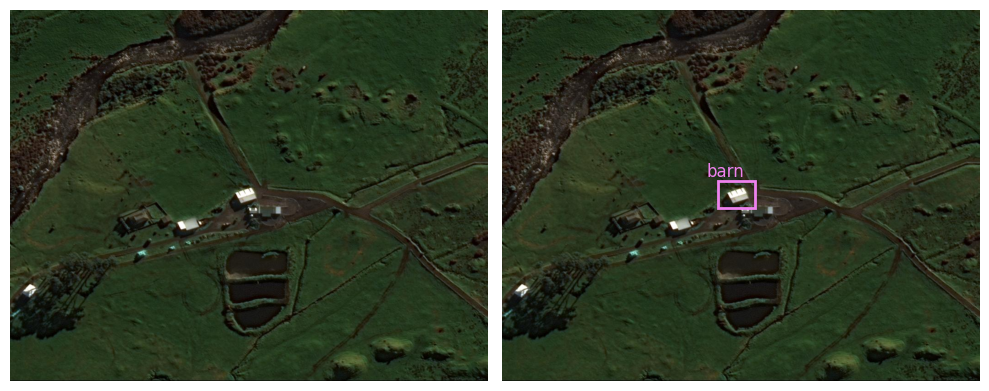

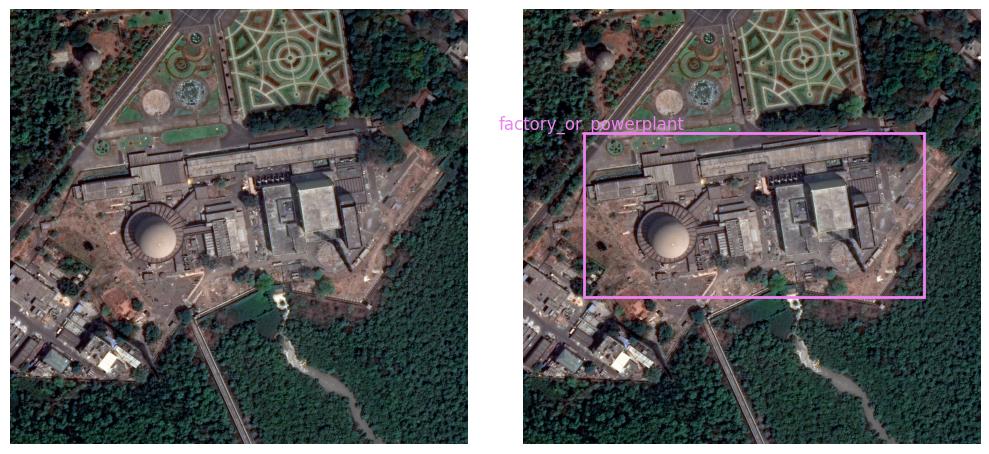

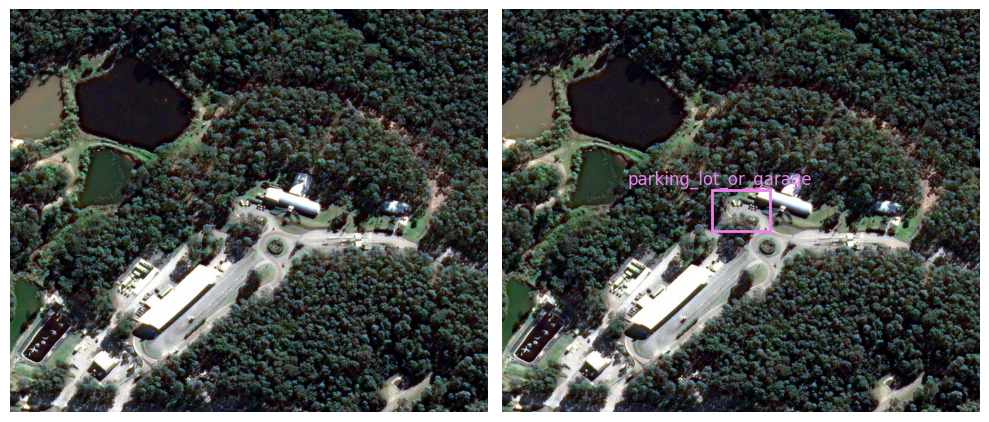

In [7]:
dataset.show_image(10);
dataset.show_image(50);
dataset.show_image(100);

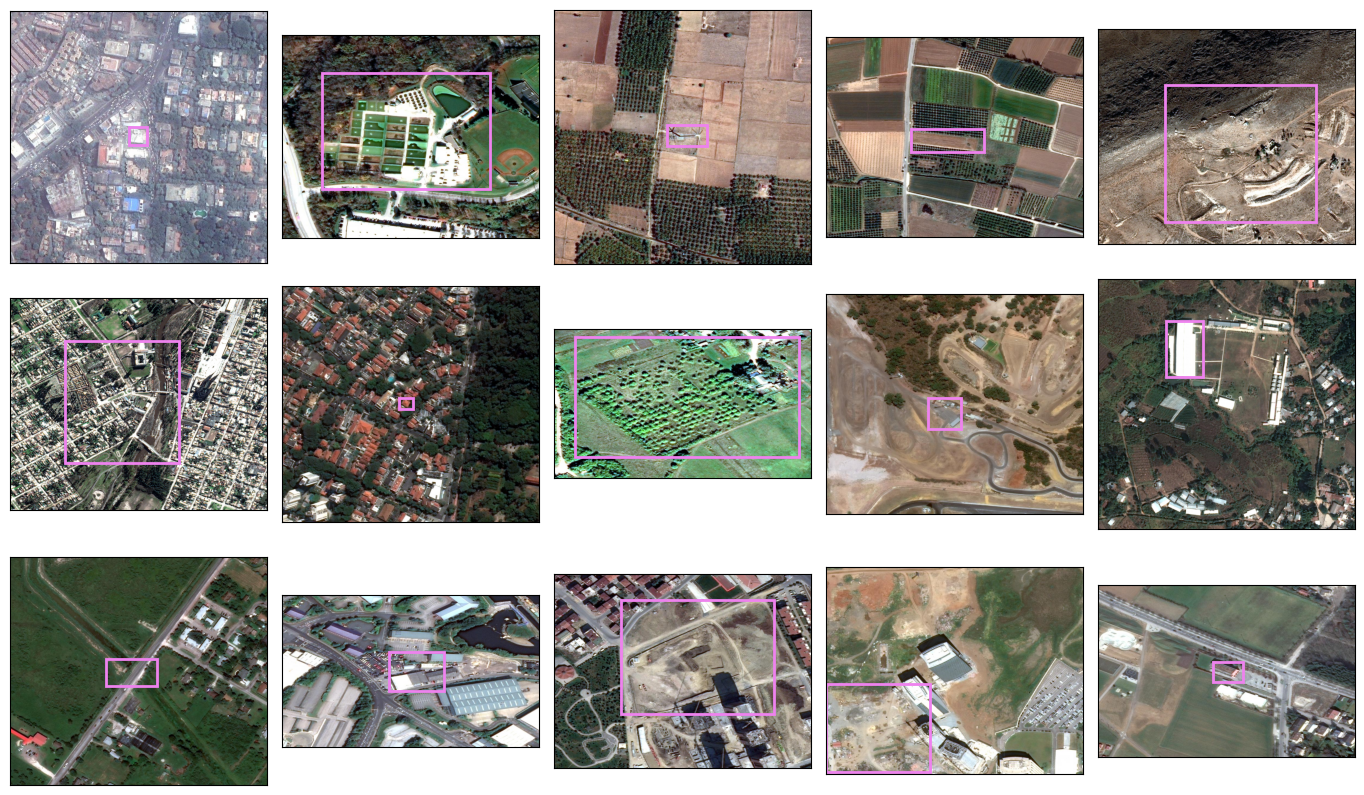

In [8]:
dataset.show_batch(15);

In [9]:
dataset.data_distribution_table()

,Label,Count
0,airport,1434
1,airport_hangar,4972
2,airport_terminal,4582
3,amusement_park,5888
4,aquaculture,1644
...,...,...
56,tunnel_opening,6330
57,waste_disposal,4301
58,water_treatment_facility,5517
59,wind_farm,5156


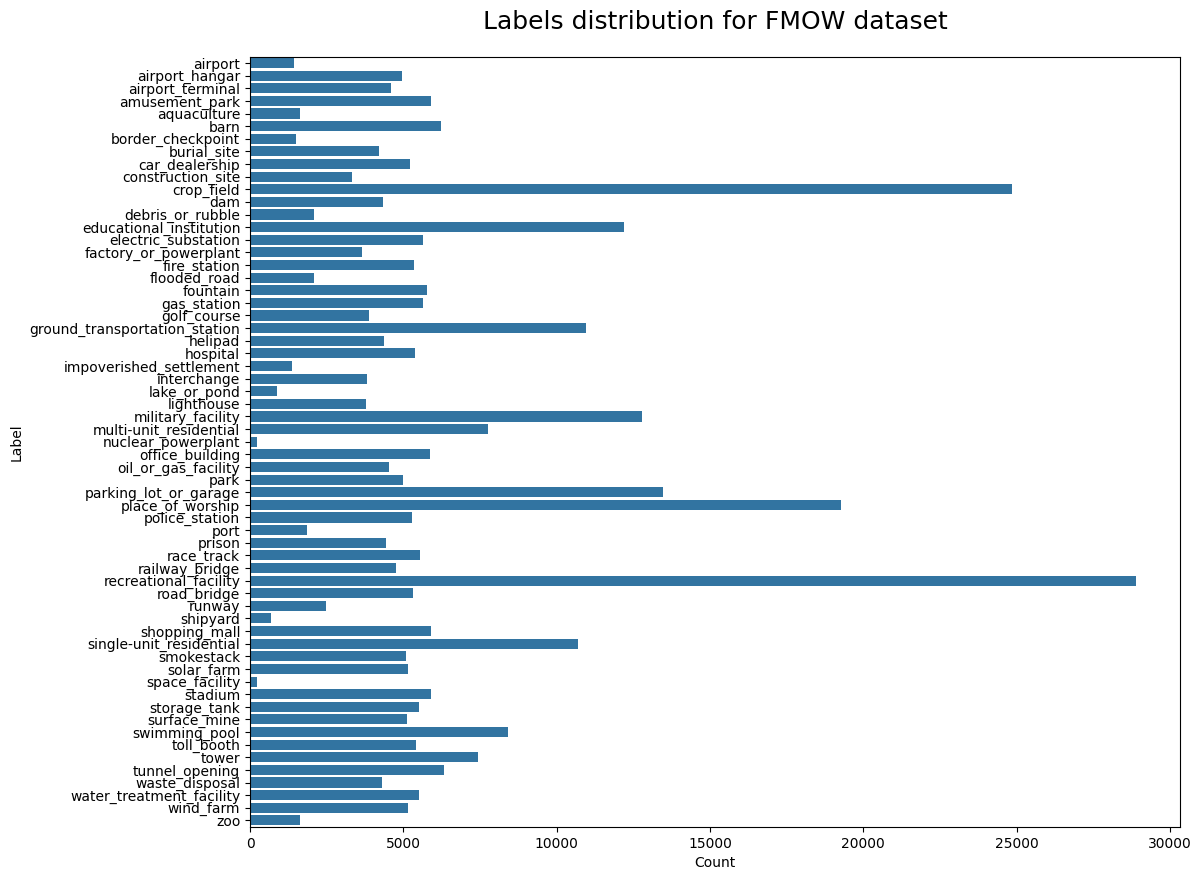

In [10]:
dataset.data_distribution_barchart();

#### 1.1 Example: Get feature embeddings for multiple RGB images as input

In [ ]:
import os
import torch
from aitlas.utils import image_loader
from aitlas.transforms import ResizeCenterCropToTensor

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define the number of images you want to load
N_batch = 4 

# Make sure we don't request more images than are in the dataset
if N_batch > len(dataset):
    raise ValueError(f"Requested {N_batch} images, but dataset only has {len(dataset)}.")

# This list will hold all processed image tensors
image_tensors = []

# Load and process N_batch images
for i in range(N_batch):  
    # Construct the full path to image
    path_to_image = os.path.join(dataset.data_dir, dataset.file_names[i]) 
    # Load the image
    image = image_loader(path_to_image)
    # Transform the image
    transform = ResizeCenterCropToTensor()
    image = transform(image) # Do not add a batch dimension this time
    # Add the processed tensor to the list of image tensors
    image_tensors.append(image)

# Combine the list of tensors into a single batch tensor
image_batch = torch.stack(image_tensors, dim=0) # The final shape will be (N_batch, C, H, W).

# Move the model, and images to the selected device
model = model.to(device)
image_batch = image_batch.to(device)

# Get feature embeddings using the SatMAE++ model
embeddings = model.forward_features(image_batch)

# Print the input image shape and the embeddings shape
print(f"Input image shape: {image.shape}")
print(f"Input batch shape: {image_batch.shape}")
print(f"Embeddings shape: {embeddings.shape}")

Using device: cuda
Input image shape: torch.Size([3, 224, 224])
Input batch shape: torch.Size([4, 3, 224, 224])
Embeddings shape: torch.Size([4, 1024])


### 2. Multispectral image examples (using SEN12MS dataset)

Prepare the SatMAE++ model (multispectral)

In [20]:
from aitlas.models import SatMAE_plusplus

model_config = {
        "local_model_path": "tests/checkpoints/checkpoint_ViT-L_pretrain_fmow_sentinel.pth",
        "backbone_name": "mae_vit_large_multispectral",
        "pretrained": True
    }

model = SatMAE_plusplus(model_config)

Loading weights from the provided local path: tests/checkpoints/checkpoint_ViT-L_pretrain_fmow_sentinel.pth


Successfully loaded checkpoint: checkpoint_ViT-L_pretrain_fmow_sentinel.pth


Load an example dataset with multispectral images (13 bands)

In [13]:
dataset_config = {
    "data_dir": "/home/dragik/data/FAIR_EO/SEN12MS/images/s2",
    "csv_file": "/home/dragik/data/FAIR_EO/SEN12MS/val.csv",
}
dataset = SEN12MSDataset(dataset_config)

print(f"Total number of patches: {len(dataset)}")

Total number of patches: 17929


Plot images and show data distribution

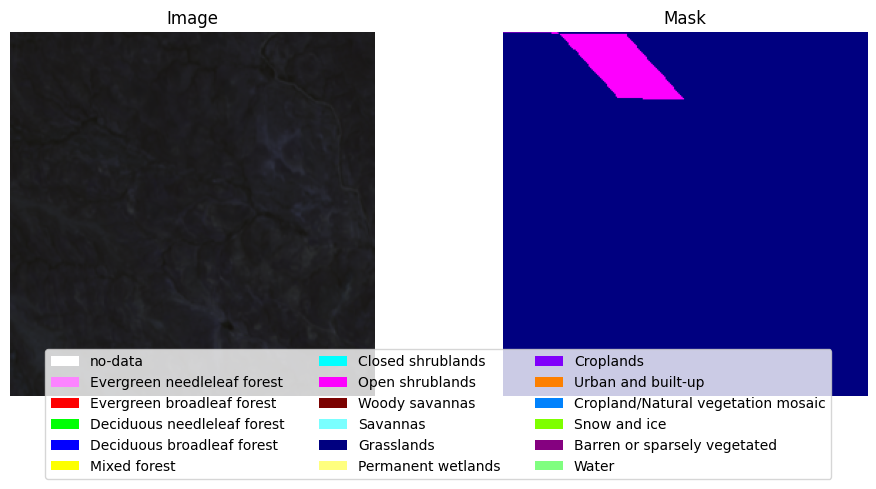

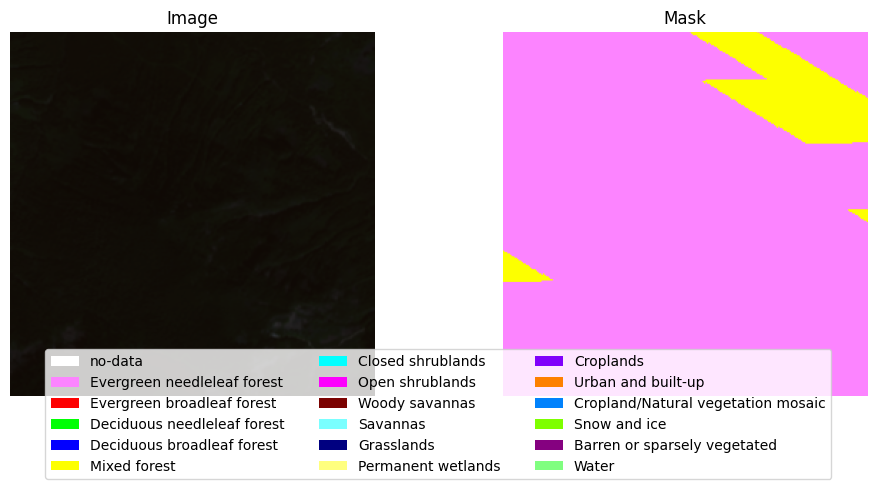

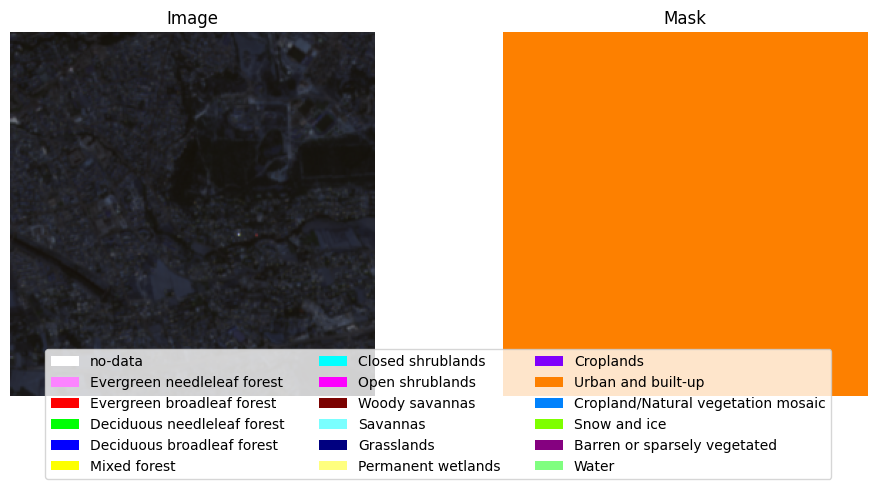

In [14]:
dataset.show_image(10);
dataset.show_image(50);
dataset.show_image(100);

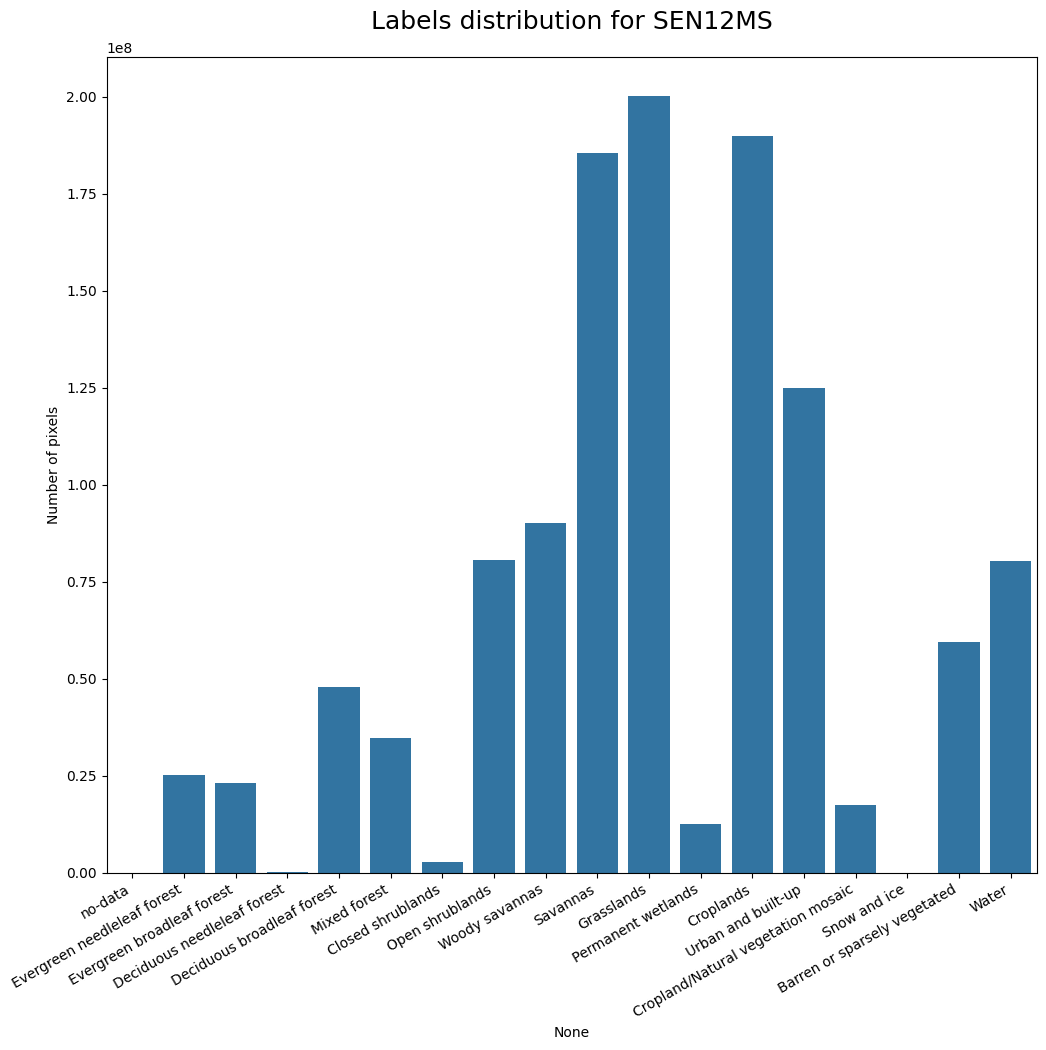

In [15]:
dataset.data_distribution_barchart();

#### 2.1 Example: Get feature embeddings for a multispectral images as input

In [21]:
from aitlas.utils import image_loader
from aitlas.transforms import Transpose, ResizePerChannelToTensor
from torchvision.transforms import v2

# Define the number of images you want to load
N_batch = 4 

# Make sure we don't request more images than are in the dataset
if N_batch > len(dataset):
    raise ValueError(f"Requested {N_batch} images, but dataset only has {len(dataset)}.")

# Sentinel-2 bands wavelengths in micrometers
bands = {
    'B01': 0.443, 'B02': 0.490, 'B03': 0.560, 'B04': 0.665,
    'B05': 0.705, 'B06': 0.740, 'B07': 0.783, 'B08': 0.842,
    'B8A': 0.865, 'B09': 0.945, 'B10': 1.375, 'B11': 1.610,
    'B12': 2.190
}
s2_bands = ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12'] # According to SatMAE and SatMAE++ papers, these spectral bands are used as input in the model
all_s2_bands_list = list(bands.keys())
s2_band_indices = [all_s2_bands_list.index(b) for b in s2_bands]

# Normalization constants (SatMAE++ requires all images to be normalized)
MEAN_S2 = torch.tensor([
        4304.32958984375,
        4159.2666015625,
        4057.776611328125,
        4328.951171875,
        4571.22119140625,
        4644.87109375,
        4837.2470703125,
        4700.2578125,
        2823.264404296875,
        2319.97021484375
    ]).float()
STD_S2 = torch.tensor([
        3537.99755859375,
        3324.23486328125,
        3270.070068359375,
        3250.530029296875,
        2897.391357421875,
        2754.4970703125,
        2821.521484375,
        2625.952392578125,
        1731.56298828125,
        1549.3028564453125
    ]).float()

# This list will hold each processed image tensor
image_tensors = []

# Load and process N_batch images
for i in range(N_batch):   
    # Load the image
    image = image_loader(dataset.images[i])[:,:,s2_band_indices]
    # Transpose and transform the image
    transpose = Transpose()
    image = transpose(image) # Change from (H, W, C) to (C, H, W)
    image = (image - MEAN_S2[:, None, None]) / STD_S2[:, None, None] # Normalization (required by SatMAE++)
    transform = ResizePerChannelToTensor()
    image = transform(image)  # Do not add a batch dimension this time
    # Crop the image to 224x224 (center crop)
    image = v2.CenterCrop(224)(image)
    # Resize the image to 96x96 (expected input as per SatMAE++ paper)
    image = v2.Resize(96)(image)
    # Add the processed tensor to the list of image tensors
    image_tensors.append(image)

# Combine the list of tensors into a single batch tensor
image_batch = torch.stack(image_tensors, dim=0) # Shape: (N_batch, C, H, W)

# Get the feature embeddings
embeddings = model.forward_features(image_batch) 

# Print the input image shape and the embeddings shape
print(f"Input image shape: {image.shape}")
print(f"Input batch shape: {image_batch.shape}")
print(f"Embeddings shape: {embeddings.shape}")

Input image shape: torch.Size([10, 96, 96])
Input batch shape: torch.Size([4, 10, 96, 96])
Embeddings shape: torch.Size([4, 1024])
